In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import ClipTypes, Session, OdometerTicks, OdometerTickRange, ViewDistance
from ilipy.database import DistanceCorrelation
from ilipy import  Session

from ilipyutils.beamforming import Beamformer
from ilipyutils.configs import FF_DEFAULTS

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.dataset import NumpyImageFolder
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [3]:
run_number = 3
root_dir = f"./data/fhr{run_number}/test"
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [4]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [5]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    transform = transforms.Compose([
        transforms.Lambda(resize_to_224),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.expand(3, -1, -1)),
        transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    ])

    wrapped_model = PreprocessingModel(model, transform)
    return wrapped_model

In [6]:
model = load_model("resnet", 128, 0.5, "models/dent_models/resnet_final.pth")

In [ ]:
def gen_image(img_start, length = 0.3, show_im=True):
    
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(arm_angles, num_tick_samples=num_tick_samples, normalize=True)
    # img = np.roll(img, shift=100)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


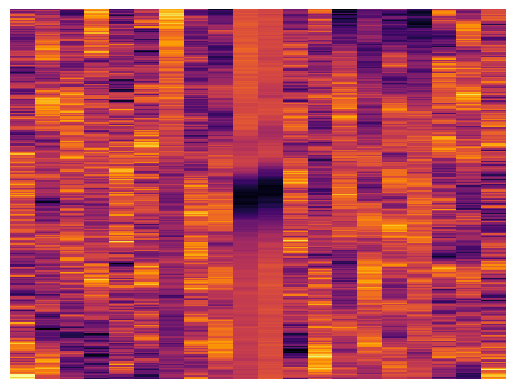

tensor(11)
0.9899429


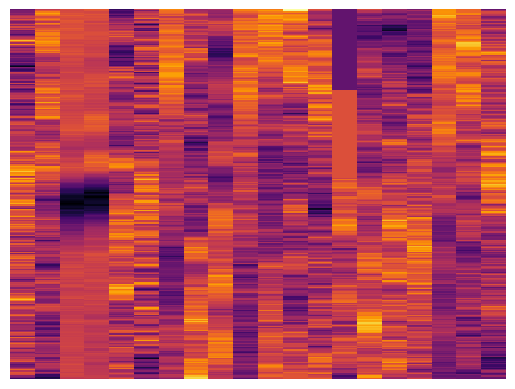

tensor(0)
0.7062572


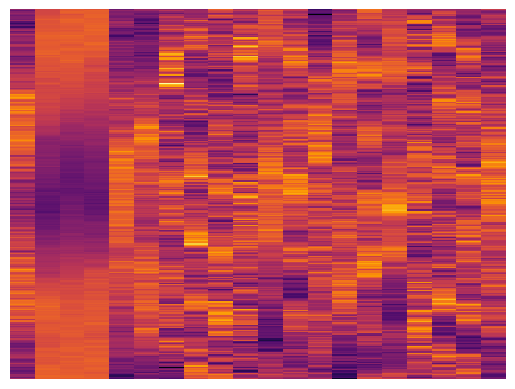

tensor(3)
0.9903957


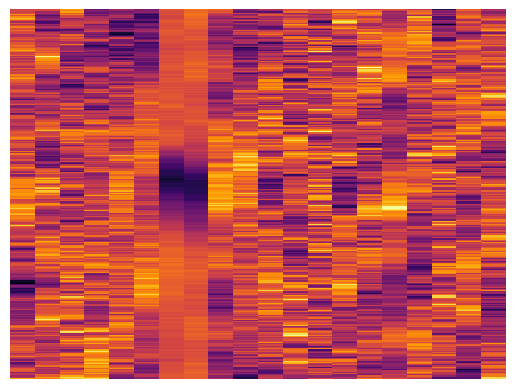

tensor(8)
0.9988217


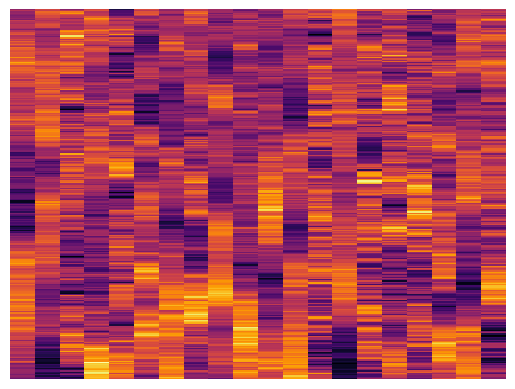

tensor(0)
0.8851159


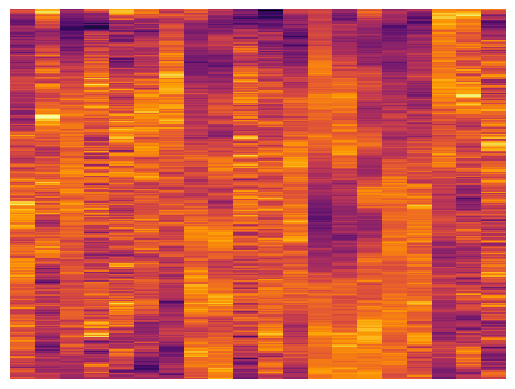

tensor(14)
0.4751708


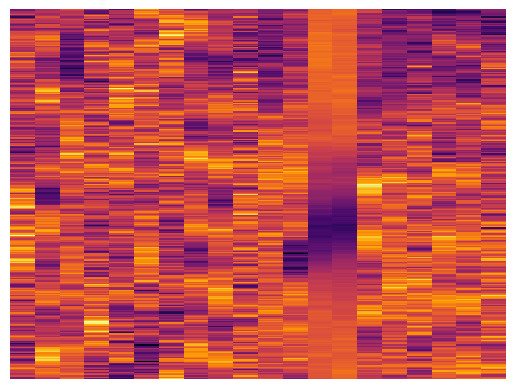

tensor(13)
0.6899795


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [10]:
model.eval()
with torch.no_grad():
    for img_start in [943, 983.5, 5062.75, 6582.2, 8177.4, 15263, 21683.7]:
        img = gen_image(img_start, show_im=True)
        raw_outputs = model(img)
        preds = raw_outputs.argmax()
        probs = raw_outputs.softmax(dim=1).cpu().numpy().max()
        print(preds)
        print(probs)

In [9]:
model.eval()
preds = []
probs = []
with torch.no_grad():
    for img_start in np.arange(6000, 7000, 0.3):
        img = gen_image(img_start, show_im=False)
        raw_outputs = model(img)
        preds.append(raw_outputs.argmax())
        probs.append(raw_outputs.softmax(dim=1).cpu().numpy().max())

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


KeyboardInterrupt: 

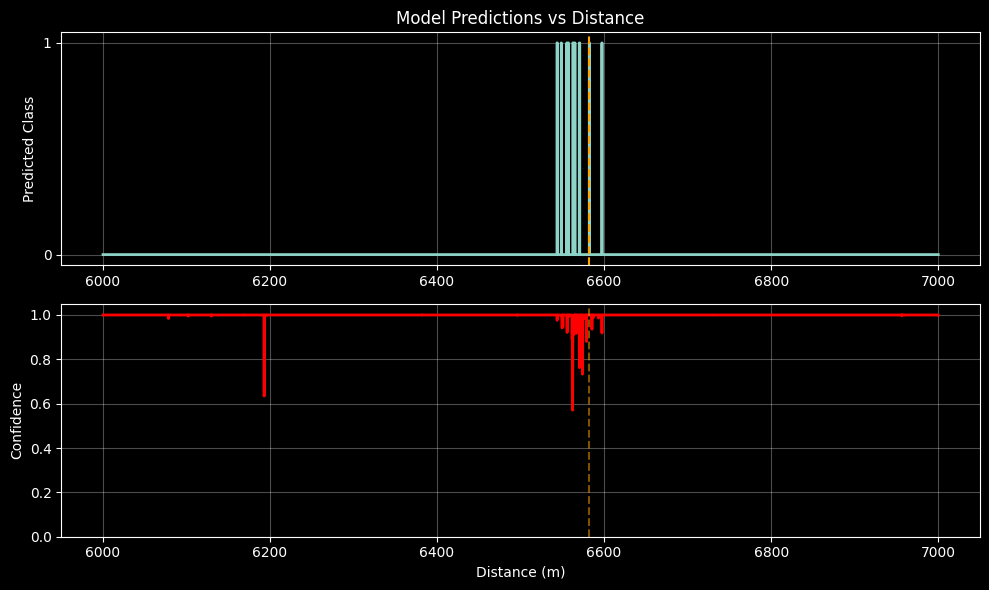

In [ ]:
# Plot predictions
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Create x-axis points
patch_length = 0.3
x_points = np.arange(6000, 7000, patch_length)

# Plot class predictions (0 or 1)
plt.subplot(2, 1, 1)
plt.step(x_points+patch_length/2, preds, where='mid', linewidth=2)
plt.ylabel('Predicted Class')
plt.title('Model Predictions vs Distance')
plt.axvline(x=6582.2, color='orange', linestyle='--', label='Reference Point')
plt.grid(True, alpha=0.3)
plt.yticks([0, 1])

# Plot confidence probabilities
plt.subplot(2, 1, 2)
plt.plot(x_points+0.15, probs, 'r-', linewidth=2)
plt.xlabel('Distance (m)')
plt.ylabel('Confidence')
plt.axvline(x=6582.2, color='orange', linestyle='--', label='Reference Point', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()